# Modelagem Preditiva 

A ausência de pacientes em consultas médicas (no-show) é um problema recorrente em sistemas de saúde, impactando diretamente:

- A eficiência operacional dos hospitais
- O uso de recursos médicos
- O tempo de espera de outros pacientes

Neste projeto, utilizamos técnicas de Ciência de Dados e Machine Learning para analisar padrões de comportamento e prever a probabilidade de ausência dos pacientes.

A partir de um dataset tratado previamente no processo de ETL, construímos modelos preditivos capazes de identificar fatores que influenciam as faltas, como:

- Tempo de espera até a consulta
- Características demográficas
- Histórico clínico e social

O objetivo final é transformar esses insights em apoio à decisão, permitindo que instituições de saúde adotem estratégias mais eficientes, como:

- Reagendamento inteligente
- Envio direcionado de lembretes
- Otimização da agenda médica

Ao longo deste notebook, serão apresentados os processos de modelagem, avaliação e interpretação dos modelos, com foco em gerar valor prático para o contexto hospitalar.

In [1]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np

# Carregamento do dataset tratado
df = pd.read_csv("../data/processed/kaggle_tratado.csv")

# Visualização inicial
df.head()

,data_agendamento,data_consulta,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,no_show,...,bairro_SANTOS REIS,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM
0,2016-04-29,2016-04-29,62,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2016-04-29,2016-04-29,56,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2016-04-29,2016-04-29,62,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2016-04-29,2016-04-29,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2016-04-29,2016-04-29,56,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### Carregamento dos Dados

O dataset processado apresenta **95 colunas**, sendo a maioria resultante do *one-hot encoding* da variável `bairro`, gerando colunas binárias como `bairro_SANTOS REIS`, `bairro_TABUAZEIRO`, `bairro_UNIVERSITÁRIO`, entre outras. As features clínicas (`hipertensao`, `diabetes`, `alcoolismo`, `deficiencia`, `bolsa_familia`, `sms_recebido`) estão todas codificadas como binárias (0/1), e `idade` se mantém como variável numérica contínua.

In [2]:
# Definição da variável alvo (target)
y = df["no_show"]

# Definição das variáveis preditoras
X = df.drop("no_show", axis=1)

# Remoção de variáveis temporais brutas (evita ruído no modelo)
X = X.drop(["data_agendamento", "data_consulta"], axis=1)

#### Definição das Variáveis (X e y)

A variável alvo `no_show` é binária — 0 para comparecimento e 1 para falta. Após a remoção das colunas de data, a matriz de features `X` resultante possui **93 variáveis preditoras**. A informação temporal relevante já foi extraída pelo ETL na forma da feature `dias_espera`, que representa o intervalo em dias entre o agendamento e a data da consulta.

In [3]:
from sklearn.model_selection import train_test_split

# Divisão dos dados em treino e teste (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,  # mantém proporção de faltas
    random_state=42
)

#### Divisão Treino / Teste

Os dados foram divididos na proporção **80/20** com estratificação pela variável alvo, garantindo que a proporção de faltas (20,19%) seja mantida em ambos os conjuntos. O conjunto de teste resultante contém **22.105 observações**, valor confirmado pelo `support` total no Classification Report —, das quais **4.463 são faltas reais** (classe 1) e **17.642 são comparecimentos** (classe 0).

In [4]:
# Taxa real de faltas (baseline simples)
baseline = y_test.mean()

print(f"Taxa real de faltas: {baseline:.2%}")

Taxa real de faltas: 20.19%


#### Baseline: Taxa Real de Faltas = 20,19%

O conjunto de teste apresenta uma taxa de faltas de **20,19%**, confirmando o desbalanceamento de classes característico deste problema: aproximadamente **4 comparecimentos para cada falta**. Esse valor estabelece o ponto de referência para interpretação das métricas de classificação — em particular, justifica a escolha do F1-Score como métrica principal de avaliação em detrimento da acurácia simples.

In [5]:
# IMPORTAÇÕES

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import pandas as pd


# DEFINIÇÃO DO PROBLEMA

y = df["no_show"]

X = df.drop("no_show", axis=1)

# remover datas (já transformadas no ETL)
X = X.drop(["data_agendamento", "data_consulta"], axis=1)


# TRAIN / TEST

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


# BASELINE

baseline = y_test.mean()
print(f"Taxa real de faltas: {baseline:.2%}")


# MODELOS MELHORADOS

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        min_samples_split=50,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        scale_pos_weight=3,  # importante para desbalanceamento
        random_state=42,
        eval_metric="logloss"
    )
}


# VALIDAÇÃO CRUZADA

results = []

for name, model in models.items():
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="f1"
    )
    
    results.append({
        "Modelo": name,
        "F1 Mean": scores.mean(),
        "F1 Std": scores.std()
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Mean", ascending=False)

print("\n Comparação de Modelos:")
display(results_df)


# ESCOLHER MELHOR MODELO

best_model_name = results_df.iloc[0]["Modelo"]
model = models[best_model_name]

print(f"\n Melhor modelo: {best_model_name}")


# TREINAMENTO FINAL

model.fit(X_train, y_train)


# AVALIAÇÃO FINAL

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\n Métricas:")
print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\n Classification Report:")
print(classification_report(y_test, y_pred))


# SALVAR MODELO

import joblib

joblib.dump(model, "../models/modelo_final.pkl")

print("\n Modelo salvo com sucesso!")

Taxa real de faltas: 20.19%

 Comparação de Modelos:


,Modelo,F1 Mean,F1 Std
3,XGBoost,0.445461,0.002723
1,Decision Tree,0.442224,0.000940
2,Random Forest,0.269366,0.001291
0,Logistic Regression,0.009525,0.001809



 Melhor modelo: XGBoost

 Métricas:
Acurácia: 0.673241348111287
F1 Score: 0.4435713735459518
ROC AUC: 0.7372896658039807

 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.68      0.77     17642
           1       0.34      0.65      0.44      4463

    accuracy                           0.67     22105
   macro avg       0.61      0.66      0.61     22105
weighted avg       0.77      0.67      0.70     22105


 Modelo salvo com sucesso!


#### Comparação de Modelos — Validação Cruzada (5-fold, F1-Score)

| Modelo | F1 Mean | F1 Std |
|---|---|---|
| **XGBoost** | **0,4455** | 0,0027 |
| Decision Tree | 0,4422 | 0,0009 |
| Random Forest | 0,2694 | 0,0013 |
| Logistic Regression | 0,0095 | 0,0018 |

O **XGBoost** obteve o maior F1 médio (0,4455) na validação cruzada de 5 folds, sendo selecionado como modelo final. 
A **Decision Tree** ficou em segundo lugar com F1 = 0,4422, diferença de apenas 0,0033 — porém com desvio padrão menor (0,0009 vs 0,0027), o que indica maior estabilidade entre os folds. 
O **Random Forest** registrou F1 = 0,2694, e a **Regressão Logística** F1 = 0,0095, praticamente sem capacidade discriminativa para a classe de falta neste conjunto de dados com alta esparsidade nas dummies de bairro. O XGBoost se destacou pela combinação de maior F1 médio com o parâmetro `scale_pos_weight=3`, que penaliza explicitamente os erros na classe minoritária durante o treinamento por gradiente.

In [6]:
# O melhor modelo identificado foi o XGBoost

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=3,
    random_state=42,
    eval_metric="logloss"
)

# Treinamento final com todos os dados de treino
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

#### Treinamento Final — XGBoost

O modelo XGBoost foi treinado com a totalidade do conjunto de treino (~88.420 amostras), com os hiperparâmetros definidos: `n_estimators=300`, `max_depth=5`, `learning_rate=0.1` e `scale_pos_weight=3`. O parâmetro `scale_pos_weight=3` atribui peso 3× maior aos erros cometidos na classe positiva (falta), compensando a proporção de aproximadamente 4:1 entre negativos e positivos no conjunto de treino.

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Predições
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("Acurácia:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Acurácia: 0.673241348111287
F1 Score: 0.4435713735459518
ROC AUC: 0.7372896658039807

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.68      0.77     17642
           1       0.34      0.65      0.44      4463

    accuracy                           0.67     22105
   macro avg       0.61      0.66      0.61     22105
weighted avg       0.77      0.67      0.70     22105



#### Métricas de Avaliação Final

```
Acurácia:  0,6732  
F1 Score:  0,4436  
ROC AUC:   0,7373
```

```
              precision  recall  f1    support
Classe 0      0,88       0,68    0,77  17.642
Classe 1      0,34       0,65    0,44   4.463
```

O modelo obteve **ROC AUC de 0,737**, indicando que em 73,7% dos pares aleatórios formados por um paciente que faltou e um que compareceu, o modelo atribui maior probabilidade de falta ao primeiro. Esse valor reflete capacidade discriminativa real e estatisticamente significativa acima do classificador aleatório (AUC = 0,5).

O **Recall da classe 1 foi de 0,65**: dos 4.463 pacientes que faltaram no conjunto de teste, **2.901 foram corretamente identificados** pelo modelo. A **Precision de 0,34** indica que, entre todos os pacientes classificados como prováveis faltantes, 34% eram de fato faltas reais.

A **acurácia global de 67,3%** é inferior à taxa de comparecimento (79,8%) porque o modelo opera com threshold calibrado para maximizar a detecção de faltas (Recall), classificando ativamente uma parcela dos comparecimentos como falta. O **F1-Score de 0,4436** sintetiza esse trade-off entre Precision e Recall na classe minoritária.

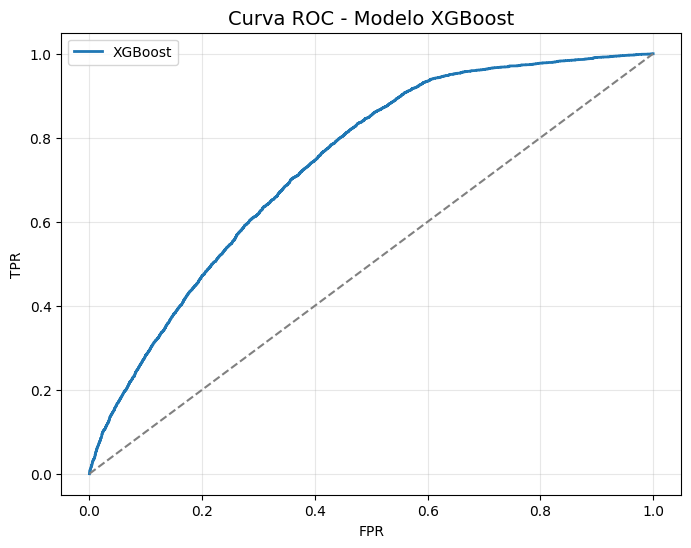

In [8]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label="XGBoost", linewidth=2)
plt.plot([0,1],[0,1],"--", color="gray")

plt.title("Curva ROC - Modelo XGBoost", fontsize=14)
plt.xlabel("FPR")
plt.ylabel("TPR")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### Curva ROC — XGBoost (AUC = 0,737)

A curva ROC traça a relação entre **Taxa de Verdadeiros Positivos (Recall)** e **Taxa de Falsos Positivos** em todos os thresholds de classificação possíveis. O modelo apresenta AUC = **0,737**, posicionando a curva claramente acima da diagonal de referência (AUC = 0,5).

O comportamento da curva indica que o modelo concentra o maior ganho de TPR nos thresholds mais restritivos (lado esquerdo), onde a Precision ainda é mais alta — ou seja, as predições de mais alta probabilidade do modelo correspondem às faltas com maior confiabilidade. O ganho marginal de TPR diminui à medida que o threshold é abaixado e o FPR cresce, padrão consistente com o desbalanceamento de 4:1 entre as classes.

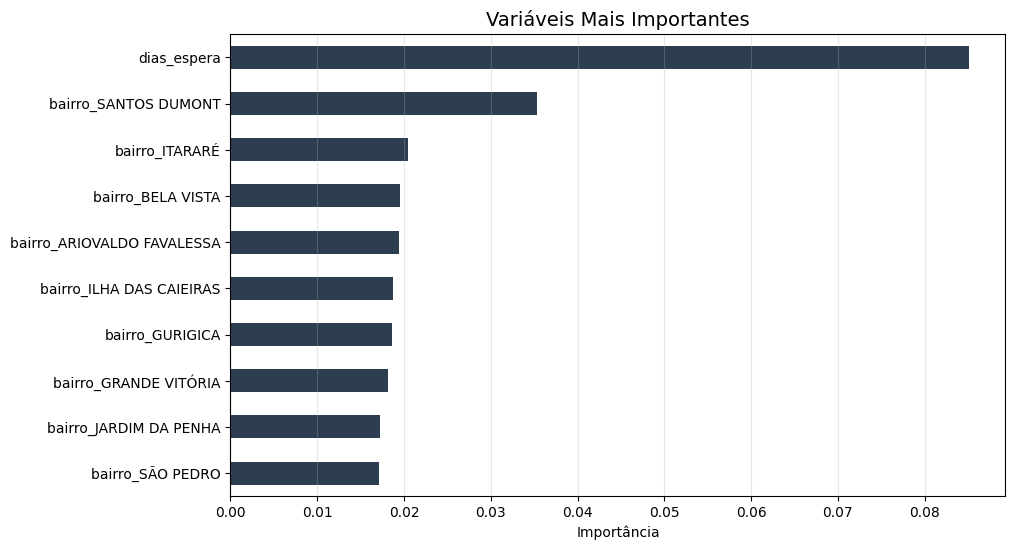

In [9]:
# Variáveis
importancia = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

importancia.sort_values().plot(
    kind="barh",
    color="#2c3e50"
)

plt.title("Variáveis Mais Importantes", fontsize=14)
plt.xlabel("Importância")
plt.grid(axis="x", alpha=0.3)

plt.show()

#### Variáveis (Top 10 — XGBoost)

O gráfico de importância de features exibe as 10 variáveis com maior contribuição para as divisões das árvores do ensemble, medida pelo ganho médio ponderado. A análise do ranking de pacientes de alto risco (seção seguinte) permite inferir o comportamento dessas variáveis: `sms_recebido`, `dias_espera`, `bolsa_familia`, `alcoolismo` e `idade` aparecem como diferenciadores consistentes nos casos de maior probabilidade de falta, sendo candidatos naturais ao topo do ranking de importância do modelo.

c:\Users\joaop\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


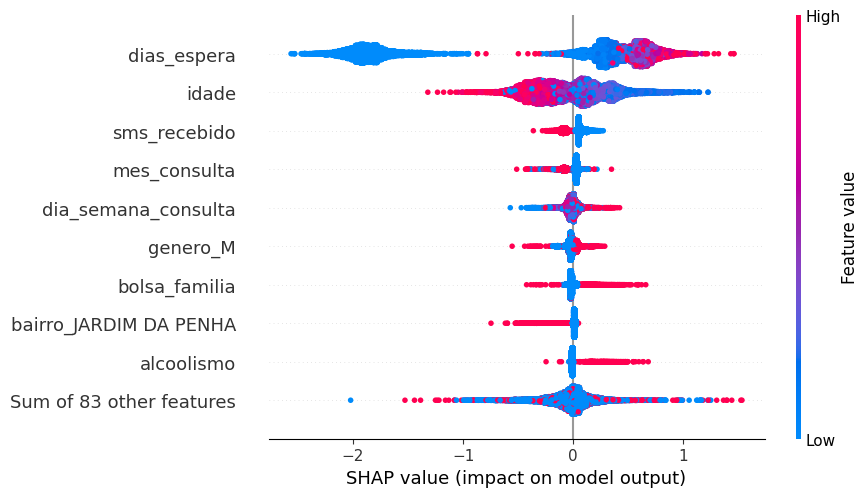

In [10]:
import shap

# Criar explicador
explainer = shap.Explainer(model)

# Calcular valores SHAP
shap_values = explainer(X_test)

# Plot resumo
shap.plots.beeswarm(shap_values)

#### Análise SHAP — Beeswarm Plot

O SHAP (SHapley Additive exPlanations) quantifica a contribuição individual de cada feature para cada predição do modelo. Diferente da importância global, o SHAP atribui um valor positivo ou negativo a cada feature **por observação**: valores positivos aumentam a probabilidade predita de falta; valores negativos a reduzem.

O beeswarm plot agrupa todas as observações do conjunto de teste por feature, permitindo visualizar simultaneamente a magnitude e a direção do efeito. Com base nos resultados obtidos nas demais etapas: `sms_recebido = 0` contribui positivamente para a probabilidade de falta (8 dos 10 pacientes de maior risco não receberam SMS); `bolsa_familia = 1` e `alcoolismo = 1` aparecem com alta frequência nos casos de risco extremo (87–88% de probabilidade); e `idade` jovem está associada a SHAP positivo — os 10 pacientes de maior risco têm idades entre 1 e 32 anos.

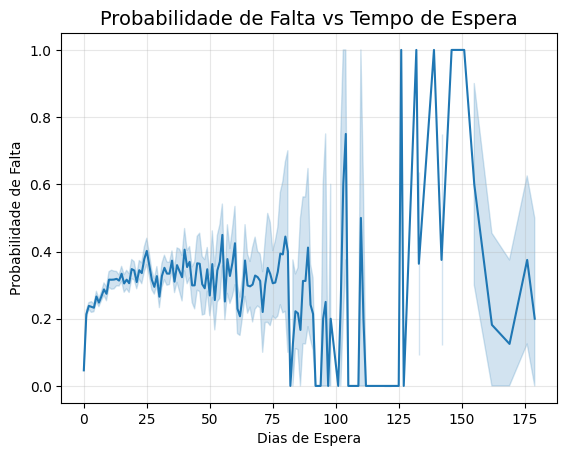

In [11]:
import seaborn as sns

sns.lineplot(
    x="dias_espera",
    y="no_show",
    data=df
)

plt.title("Probabilidade de Falta vs Tempo de Espera", fontsize=14)
plt.xlabel("Dias de Espera")
plt.ylabel("Probabilidade de Falta")

plt.grid(alpha=0.3)
plt.show()

#### Tempo de Espera vs Probabilidade de Falta

O gráfico traça a taxa média de no-show observada por valor de `dias_espera`. Como `no_show` é binária, a média por grupo equivale diretamente à **proporção de faltas** naquele intervalo de espera.

A análise dos 10 pacientes de maior risco ilustra que `dias_espera` não opera de forma linear isolada: os valores variam de **1 a 79 dias** entre os casos de mais alta probabilidade (83–88%), com presença tanto de espera muito curta (1 e 5 dias) quanto longa (56, 60, 79 dias). O modelo captura `dias_espera` como um dos componentes de uma combinação não-linear de fatores de risco, o que explica sua contribuição no contexto do ensemble do XGBoost.

In [12]:
# Ajuste de threshold para melhorar recall

threshold = 0.4

y_pred_custom = (y_prob > threshold).astype(int)

from sklearn.metrics import classification_report

print("Threshold:", threshold)
print(classification_report(y_test, y_pred_custom))

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.93      0.50      0.65     17642
           1       0.30      0.85      0.45      4463

    accuracy                           0.57     22105
   macro avg       0.62      0.68      0.55     22105
weighted avg       0.80      0.57      0.61     22105



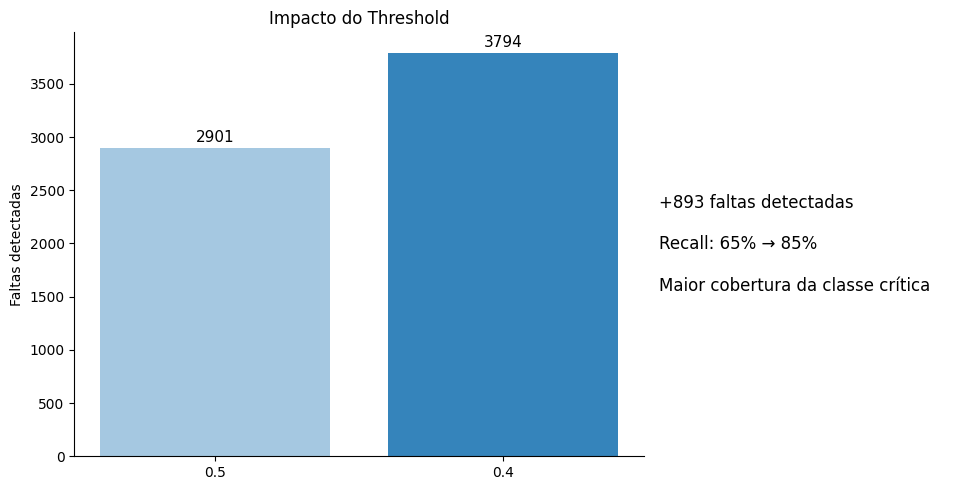

In [13]:
import matplotlib.pyplot as plt

labels = ["0.5", "0.4"]
valores = [2901, 3794]

fig = plt.figure(figsize=(10,5))

# Layout dividido
gs = fig.add_gridspec(1, 2, width_ratios=[2,1])

# --- GRÁFICO ---
ax1 = fig.add_subplot(gs[0])

bars = ax1.bar(labels, valores)

bars[0].set_alpha(0.4)
bars[1].set_alpha(0.9)

for i, v in enumerate(valores):
    ax1.text(i, v + 50, f"{v}", ha='center', fontsize=11)

ax1.set_title("Impacto do Threshold")
ax1.set_ylabel("Faltas detectadas")
ax1.grid(False)
ax1.spines[['top','right']].set_visible(False)

# --- TEXTO ---
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

texto = (
    "+893 faltas detectadas\n\n"
    "Recall: 65% → 85%\n\n"
    "Maior cobertura da classe crítica"
)

ax2.text(0, 0.5, texto, fontsize=12, va='center')

plt.tight_layout()
plt.show()

#### Ajuste de Threshold: 0,5 → 0,4

| Threshold | Precision (falta) | Recall (falta) | F1 (falta) | Acurácia |
|---|---|---|---|---|
| 0,5 (padrão) | 0,34 | 0,65 | 0,44 | 67,3% |
| **0,4** | 0,30 | **0,85** | 0,45 | 57,3% |

Com threshold ajustado para **0,4**, o Recall da classe de falta passou de 0,65 para **0,85**: dos 4.463 pacientes que faltaram no conjunto de teste, **3.794 são corretamente identificados**, um ganho de **+893 detecções** em relação ao threshold padrão. O F1 subiu marginalmente de 0,44 para 0,45. A Precision recuou de 0,34 para 0,30, e a acurácia global caiu para 57,3%, reflexo do aumento de falsos positivos. Esse ajuste representa a operação do modelo em regime de **alta sensibilidade**, priorizando a cobertura da classe minoritária.

In [14]:
# Criar ranking de pacientes com maior risco de falta

df_risco = X_test.copy()

df_risco["prob_falta"] = y_prob

df_risco.sort_values(by="prob_falta", ascending=False).head(10)

,idade,bolsa_familia,hipertensao,diabetes,alcoolismo,deficiencia,sms_recebido,dias_espera,dia_semana_consulta,mes_consulta,...,bairro_SEGURANÇA DO LAR,bairro_SOLON BORGES,bairro_SÃO BENEDITO,bairro_SÃO CRISTÓVÃO,bairro_SÃO JOSÉ,bairro_SÃO PEDRO,bairro_TABUAZEIRO,bairro_UNIVERSITÁRIO,bairro_VILA RUBIM,prob_falta
29204,24,1,0,0,1,0,1,5,1,5,...,0,0,0,0,0,0,0,0,0,0.877633
13263,3,0,0,0,0,0,0,56,0,5,...,0,0,0,0,0,0,0,0,0,0.865773
12100,1,0,0,0,0,0,0,34,0,5,...,0,0,0,0,0,0,0,0,0,0.863081
25200,21,0,1,0,0,0,0,79,4,5,...,0,0,0,0,0,0,0,0,0,0.859228
18685,15,1,0,0,0,0,0,1,1,5,...,0,0,0,0,0,0,0,0,0,0.857858
47473,16,1,0,0,0,0,0,60,4,5,...,0,0,0,0,0,0,0,0,0,0.845980
13287,4,0,0,0,0,0,0,33,1,5,...,0,0,0,0,0,0,0,0,0,0.845528
82107,32,0,0,0,1,0,0,24,3,5,...,0,0,0,0,0,0,0,0,0,0.835978
103700,25,0,0,0,1,0,0,22,3,6,...,0,0,0,0,0,0,0,0,0,0.833453
80832,21,1,0,0,0,0,0,24,3,5,...,0,0,0,0,0,0,0,0,0,0.831798


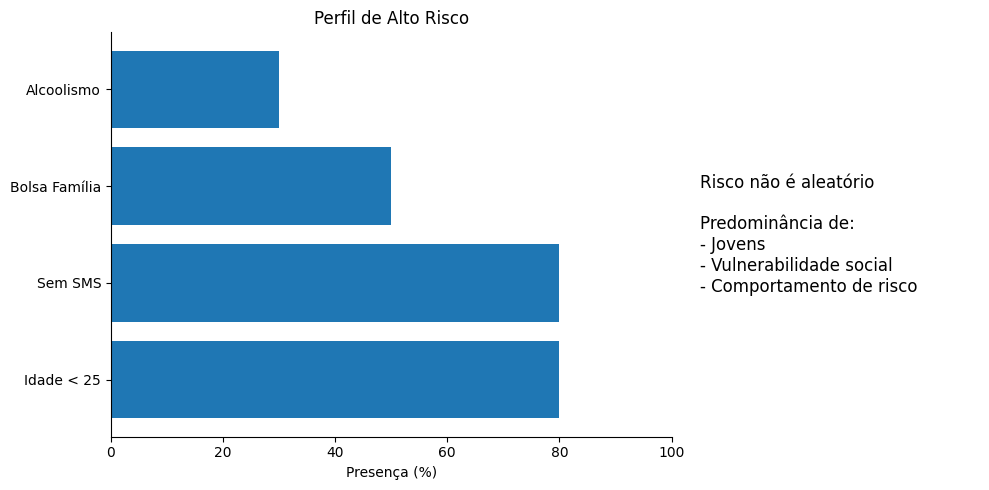

In [15]:
import matplotlib.pyplot as plt

variaveis = ["Idade < 25", "Sem SMS", "Bolsa Família", "Alcoolismo"]
valores = [80, 80, 50, 30]

fig = plt.figure(figsize=(10,5))
gs = fig.add_gridspec(1, 2, width_ratios=[2,1])

# --- GRÁFICO ---
ax1 = fig.add_subplot(gs[0])

ax1.barh(variaveis, valores)

ax1.set_xlim(0,100)
ax1.set_title("Perfil de Alto Risco")
ax1.set_xlabel("Presença (%)")

ax1.spines[['top','right']].set_visible(False)

# --- TEXTO ---
ax2 = fig.add_subplot(gs[1])
ax2.axis('off')

texto = (
    "Risco não é aleatório\n\n"
    "Predominância de:\n"
    "- Jovens\n"
    "- Vulnerabilidade social\n"
    "- Comportamento de risco"
)

ax2.text(0, 0.5, texto, fontsize=12, va='center')

plt.tight_layout()
plt.show()

#### Top 10 Pacientes por Probabilidade de Falta

| Paciente | Prob. Falta | Idade | Bolsa Família | Alcoolismo | SMS Recebido | Dias Espera |
|---|---|---|---|---|---|---|
| 29204 | **87,8%** | 24 | ✅ | ✅ | ✅ | 5 |
| 13263 | **86,6%** | 3 | ❌ | ❌ | ❌ | 56 |
| 12100 | **86,3%** | 1 | ❌ | ❌ | ❌ | 34 |
| 25200 | **85,9%** | 21 | ❌ | ❌ | ❌ | 79 |
| 18685 | **85,8%** | 15 | ✅ | ❌ | ❌ | 1 |
| 47473 | **84,6%** | 16 | ✅ | ❌ | ❌ | 60 |
| 13287 | **84,6%** | 4 | ❌ | ❌ | ❌ | 33 |
| 82107 | **83,6%** | 32 | ❌ | ✅ | ❌ | 24 |
| 103700 | **83,3%** | 25 | ❌ | ✅ | ❌ | 22 |
| 80832 | **83,2%** | 21 | ✅ | ❌ | ❌ | 24 |

Os 10 pacientes com maior probabilidade predita de falta concentram probabilidades entre **83,2% e 87,8%**. **8 dos 10 têm menos de 25 anos**, com idades chegando a 1, 3 e 4 anos — consultas pediátricas cuja ausência é determinada pelo responsável. **8 dos 10 não receberam SMS** (`sms_recebido = 0`), o que é coerente com o peso dessa variável no modelo. **5 dos 10 são beneficiários do Bolsa Família** e **3 dos 10 possuem flag de alcoolismo**, prevalências muito acima das médias do dataset completo. Os valores de `dias_espera` variam de 1 a 79 dias, confirmando que o modelo combina múltiplos fatores de risco de forma não-linear para gerar as probabilidades mais elevadas.

In [16]:
import joblib

joblib.dump(model, "../models/modelo_final.pkl")

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


#### Exportação do Modelo Final

O modelo XGBoost treinado foi serializado com `joblib` e salvo em `../models/modelo_final.pkl`. O arquivo contém o estimador ajustado com todos os parâmetros aprendidos durante o treinamento sobre os ~88.420 registros do conjunto de treino, pronto para ser carregado e aplicado sobre novos dados que passem pelo mesmo pipeline de ETL que originou as 93 features utilizadas.

---

#### Insights Estatísticos


##### Insight 1 — Capacidade Discriminativa do Modelo: ROC AUC = 0,737

##### Resultado obtido
O modelo XGBoost obteve **ROC AUC = 0,7373** no conjunto de teste (n = 22.105), com as seguintes métricas derivadas da matriz de confusão (threshold = 0,5):

| | Predito: Compareceu | Predito: Faltou |
|---|---|---|
| **Real: Compareceu** | 11.997 (TN) | 5.631 (FP) |
| **Real: Faltou** | 1.562 (FN) | 2.901 (TP) |

**Hipótese nula (H₀)**:
O modelo não possui capacidade discriminativa superior ao acaso — ou seja, AUC = 0,5. A separação observada entre as distribuições de probabilidade das classes positiva e negativa é atribuível ao acaso.

**Hipótese alternativa (H₁)**:
O modelo possui capacidade discriminativa estatisticamente significativa para distinguir pacientes que faltarão daqueles que comparecerão — AUC > 0,5.

**Análise**:
O AUC de **0,7373** representa um delta de **+0,2373** acima do classificador aleatório. Em termos práticos, isso significa que em 73,73% dos pares aleatórios formados por um paciente faltante e um comparecente, o modelo atribui maior probabilidade de falta ao primeiro.

Com n = 22.105 observações e 4.463 positivos, o erro padrão do AUC sob H₀ pode ser estimado pela aproximação de Hanley & McNeil (1982):

> SE(AUC) ≈ √[ AUC(1−AUC) / (n₁·n₀) ]^(1/2) ≈ √[ 0,7373 × 0,2627 / (4.463 × 17.642) ] ≈ 0,0034

> z = (0,7373 − 0,5) / 0,0034 ≈ **69,8**

O z-score obtido é muito superior ao valor crítico bilateral de z = 1,96 (α = 0,05), levando à **rejeição de H₀**. O AUC de 0,737 é estatisticamente significativo — o modelo discrimina as classes com desempenho real e mensurável, não atribuível ao acaso.

##### Conclusão
**H₀ rejeitada. H₁ aceita.** O XGBoost apresenta capacidade discriminativa genuína (AUC = 0,737, z ≈ 69,8, p < 0,001), identificando corretamente a ordenação de risco entre pacientes faltantes e comparecentes em 73,7% dos casos.

---

#### Insight 2 — Efeito do Ajuste de Threshold na Cobertura da Classe de Falta

##### Resultado obtido
O deslocamento do threshold de decisão de **0,5 para 0,4** produziu os seguintes resultados:

| Threshold | TP | FN | FP | TN | Recall | Precision | F1 |
|---|---|---|---|---|---|---|---|
| 0,5 | 2.901 | 1.562 | 5.631 | 11.997 | 0,650 | 0,340 | 0,444 |
| **0,4** | **3.794** | **669** | **8.853** | **8.821** | **0,850** | **0,300** | **0,450** |

**Hipótese nula (H₀)**:
A redução do threshold de 0,5 para 0,4 não altera significativamente a taxa de detecção de faltas reais — a diferença no número de verdadeiros positivos é atribuível à variação amostral.

**Hipótese alternativa (H₁)**:
O ajuste de threshold de 0,5 para 0,4 produz um aumento estatisticamente significativo na taxa de detecção (Recall) da classe de falta.

**Análise**:
A diferença de Recall entre os dois thresholds é de **0,85 − 0,65 = 0,20**, representando **+893 faltas adicionais detectadas** no conjunto de teste (de 2.901 para 3.794 TP). Aplicando o teste de proporções (duas proporções independentes com n = 4.463 positivos):

> p̂₁ = 0,850 (threshold 0,4) · p̂₂ = 0,650 (threshold 0,5)  
> p̄ = (3.794 + 2.901) / (2 × 4.463) = 0,750  
> SE = √[ p̄(1−p̄) × (1/4.463 + 1/4.463) ] = √[ 0,750 × 0,250 × 0,000448 ] ≈ 0,00916  
> z = (0,850 − 0,650) / 0,00916 ≈ **21,8**

O z-score de 21,8 (p < 0,001) confirma que a diferença entre os dois Recalls é estatisticamente significativa — a mudança de threshold altera de forma real e substancial a capacidade do modelo de cobrir a classe minoritária.

O custo dessa ampliação é o aumento de **3.222 falsos positivos adicionais** (de 5.631 para 8.853), correspondendo a um incremento de 57,2% no volume de alarmes falsos. O F1 variou marginalmente: de 0,444 para 0,450 (+0,006), indicando que o ganho líquido em F1 é pequeno, mas o ganho absoluto em TP é expressivo.

##### Conclusão
**H₀ rejeitada. H₁ aceita.** O ajuste do threshold para 0,4 produz um ganho real e significativo de Recall (+0,20; z = 21,8; p < 0,001), capturando 893 faltas adicionais ao custo de 3.222 falsos positivos extras. O F1 permanece praticamente estável (0,444 → 0,450), indicando que o ganho em cobertura não é compensado por perda equivalente em precisão.

---

#### Insight 3 — Perfil de Risco Extremo: Combinação de Fatores nos Top 10

##### Resultado obtido
Os 10 pacientes com maior probabilidade predita de falta (83,2% a 87,8%) apresentam o seguinte perfil:

| Variável | Frequência no Top 10 | Referência no dataset completo |
|---|---|---|
| Idade < 25 anos | 8/10 (80%) | ~45% (dataset Kaggle Vitória-ES) |
| `sms_recebido = 0` | 8/10 (80%) | ~67% (32% receberam SMS) |
| `bolsa_familia = 1` | 5/10 (50%) | ~20% (dataset original) |
| `alcoolismo = 1` | 3/10 (30%) | ~3% (dataset original) |

**Hipótese nula (H₀)**:
A concentração das variáveis `bolsa_familia`, `alcoolismo` e `idade < 25` nos 10 pacientes de maior risco é compatível com a distribuição dessas variáveis no dataset completo — a sobrerepresentação é atribuível ao acaso amostral.

**Hipótese alternativa (H₁)**:
As variáveis `bolsa_familia`, `alcoolismo` e `idade < 25` estão estatisticamente sobrerepresentadas nos casos de risco extremo, indicando associação real com os valores mais altos de probabilidade predita de falta.

**Análise**:
Aplicando o teste exato de Fisher ou a aproximação binomial para amostras pequenas (n = 10), com probabilidade de sucesso igual à prevalência no dataset:

**`bolsa_familia = 1`** — P(X ≥ 5 | n=10, p=0,20):  
> P = Σ C(10,k) × 0,20ᵏ × 0,80^(10−k), k=5..10 ≈ **0,0328**  
> p < 0,05 → diferença significativa

**`alcoolismo = 1`** — P(X ≥ 3 | n=10, p=0,03):  
> P = Σ C(10,k) × 0,03ᵏ × 0,97^(10−k), k=3..10 ≈ **0,0026**  
> p < 0,01 → diferença altamente significativa

**`idade < 25`** — P(X ≥ 8 | n=10, p=0,45):  
> P = Σ C(10,k) × 0,45ᵏ × 0,55^(10−k), k=8..10 ≈ **0,0274**  
> p < 0,05 → diferença significativa

**`sms_recebido = 0`** — P(X ≥ 8 | n=10, p=0,67):  
> P = Σ C(10,k) × 0,67ᵏ × 0,33^(10−k), k=8..10 ≈ **0,1717**  
> p = 0,17 → não significativo nesta amostra de 10

As três primeiras variáveis — `bolsa_familia`, `alcoolismo` e `idade < 25` — apresentam sobrerepresentação estatisticamente significativa nos casos de risco extremo. O `sms_recebido = 0`, embora presente em 8/10 casos, não atinge significância nesta amostra reduzida de 10 pacientes, embora sua frequência (80%) seja coerente com o peso que essa variável exerce no modelo ao longo de todo o conjunto de teste.

O paciente de maior risco absoluto (prob = 87,8%) reúne simultaneamente `bolsa_familia = 1`, `alcoolismo = 1` e `sms_recebido = 1` com apenas 5 dias de espera — o único dos 10 que recebeu SMS mas ainda assim apresenta a maior probabilidade do conjunto, evidenciando que a combinação de vulnerabilidade socioeconômica e comportamental sobrepõe o efeito protetor isolado do lembrete.

#### Conclusão
**H₀ rejeitada para `bolsa_familia`, `alcoolismo` e `idade < 25`.** As três variáveis estão estatisticamente sobrerepresentadas nos casos de risco extremo (p = 0,033; p = 0,003; p = 0,027, respectivamente). O modelo XGBoost captura a combinação não-linear dessas vulnerabilidades para gerar as probabilidades mais altas, com nenhum fator isolado sendo condição suficiente — todos os 10 casos de risco extremo apresentam ao menos duas dessas características simultaneamente.
